# 04 — TimesFM (Zero-Shot, 24h-Ahead PV Forecasting)

**Model:** Google TimesFM 2.5 200M (zero-shot, no fine-tuning)  
**Task:** 24-hour-ahead PV power forecasting at 15-minute resolution (96 steps)  
**Evaluation:**
- Primary: daytime samples (solar elevation > 5°)
- Secondary: all-hours (for completeness)
- Metrics: MAE, RMSE, nRMSE, inference time per 24h window

**Run `01_data_processing.ipynb` first** to generate `data/dataset.csv`.

**Prerequisite:**
```bash
pip install timesfm
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time
import os
from tqdm import tqdm

import timesfm
import importlib.metadata

os.makedirs('../results', exist_ok=True)
os.makedirs('../figure',  exist_ok=True)


CONTEXT_LENGTH    = 512   # steps fed to model (~5.3 days at 15-min)
PREDICTION_LENGTH = 96    # 24h ahead at 15-min resolution
STRIDE            = 96    # step 1 day at a time
MAX_WINDOWS       = None  # set e.g. 10 for a quick smoke-test
MODEL_NAME        = 'TimesFM'

print(f'timesfm version : {importlib.metadata.version("timesfm")}')
print(f'Available attrs : {[a for a in dir(timesfm) if not a.startswith("_")]}')

timesfm version : 2.0.2
Available attrs : ['ForecastConfig', 'TimesFM_2p5_200M_torch', 'configs', 'timesfm_2p5', 'timesfm_2p5_torch', 'torch']


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/dataset.csv', index_col='timestamp', parse_dates=True)
df.index = df.index.tz_localize('UTC').tz_convert('Europe/Zagreb').tz_localize(None)

agg = {
    'power'             : 'sum',
    'sun_zenith'        : 'mean',
    'sun_azimuth'       : 'mean',
    'temperature'       : 'mean',
    'global_irradiance' : 'mean',
    'direct_irradiance' : 'mean',
    'diffuse_irradiance': 'mean',
}
df_full = df.resample('15min', closed='left', label='left').agg(agg)
df_full['power'] = df_full['power'].fillna(0).clip(lower=0)
wx_cols = [c for c in df_full.columns if c != 'power']
df_full[wx_cols] = df_full[wx_cols].ffill().fillna(0)
df_full['solar_elevation'] = (90 - df_full['sun_zenith']).clip(lower=0)

print(f'15-min grid shape: {df_full.shape}')
print(f'Range: {df_full.index.min()} → {df_full.index.max()}')

15-min grid shape: (171139, 8)
Range: 2018-04-17 07:15:00 → 2023-03-04 23:45:00


In [3]:
test_start = pd.Timestamp('2020-01-01')
test_end   = pd.Timestamp('2020-08-01')

full_series    = df_full['power'].values.astype(np.float32)
test_mask      = (df_full.index >= test_start) & (df_full.index <= test_end)
test_indices   = np.where(test_mask)[0]
test_start_idx = int(test_indices[0])
test_end_idx   = int(test_indices[-1])

start_positions = list(range(test_start_idx, test_end_idx - PREDICTION_LENGTH + 1, STRIDE))
if MAX_WINDOWS:
    start_positions = start_positions[:MAX_WINDOWS]

print(f'Test: {test_start.date()} → {test_end.date()}')
print(f'Rolling windows: {len(start_positions)} × {PREDICTION_LENGTH} steps')

Test: 2020-01-01 → 2020-08-01
Rolling windows: 213 × 96 steps


## 2. Load TimesFM Model

Uses the **timesfm 2.0.x API**: `from_pretrained` + `compile(ForecastConfig)`.

In [4]:
print('Loading TimesFM 2.5 200M ...')
t_load = time.time()

# timesfm 2.0.x API
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    'google/timesfm-2.5-200m-pytorch'
)

config = timesfm.ForecastConfig(
    max_context=CONTEXT_LENGTH,
    max_horizon=PREDICTION_LENGTH,
    normalize_inputs=True,   # recommended for PV data (large dynamic range)
)
model.compile(config)
API_VERSION = '2.5'

print(f'TimesFM loaded in {time.time() - t_load:.1f}s  (API v{API_VERSION})')


def predict_timesfm(context_array):
    """Run one 96-step TimesFM 2.5 forecast."""
    mean_fc, _ = model.forecast(
        horizon=PREDICTION_LENGTH,
        inputs=[context_array],      # list of numpy arrays
    )
    return np.clip(mean_fc[0], 0, None)   # shape: (PREDICTION_LENGTH,)

Loading TimesFM 2.5 200M ...


TimesFM loaded in 5.0s  (API v2.5)


## 3. Rolling 24h-Ahead Evaluation

In [5]:
n = len(start_positions)
all_preds   = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_actuals = np.zeros((n, PREDICTION_LENGTH), dtype=np.float32)
all_ts      = []
infer_times = []

for w, i in enumerate(tqdm(start_positions, desc='TimesFM rolling eval')):
    ctx_start = max(0, i - CONTEXT_LENGTH)
    context   = full_series[ctx_start:i]
    actual    = full_series[i:i + PREDICTION_LENGTH]
    ts        = df_full.index[i:i + PREDICTION_LENGTH]

    t0 = time.time()
    pred = predict_timesfm(context)
    infer_times.append(time.time() - t0)

    all_preds[w]   = pred[:PREDICTION_LENGTH]
    all_actuals[w] = actual
    all_ts.append(ts)

print(f'Done. Avg inference time: {np.mean(infer_times):.3f}s per 24h window')

TimesFM rolling eval: 100%|███████████████████| 213/213 [00:16<00:00, 12.79it/s]

Done. Avg inference time: 0.078s per 24h window


## 4. Metrics — Daytime & All-Hours

In [6]:
preds_flat   = np.clip(all_preds.ravel(), 0, None)
actuals_flat = all_actuals.ravel()
ts_flat      = pd.DatetimeIndex(np.concatenate([t.values for t in all_ts]))

solar_elev   = df_full['solar_elevation'].reindex(ts_flat).values
day_mask     = solar_elev > 5

def metrics(y_true, y_pred, label):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    nrmse = rmse / y_true.max()
    print(f'[{label}]  MAE={mae:.4f}  RMSE={rmse:.4f}  nRMSE={nrmse:.4f}')
    return mae, rmse, nrmse

print(f'\n=== {MODEL_NAME} ===')
mae_d, rmse_d, nrmse_d = metrics(actuals_flat[day_mask], preds_flat[day_mask], 'Daytime (solar_elev > 5°)')
mae_a, rmse_a, nrmse_a = metrics(actuals_flat,           preds_flat,           'All-hours')

avg_infer = np.mean(infer_times)
print(f'\nAvg inference time per 24h forecast: {avg_infer:.3f}s')
print(f'Daytime samples: {day_mask.sum()} / {len(day_mask)}')


=== TimesFM ===
[Daytime (solar_elev > 5°)]  MAE=0.1241  RMSE=0.1786  nRMSE=0.2078
[All-hours]  MAE=0.0625  RMSE=0.1268  nRMSE=0.1475

Avg inference time per 24h forecast: 0.078s
Daytime samples: 9930 / 20448


## 5. Plots

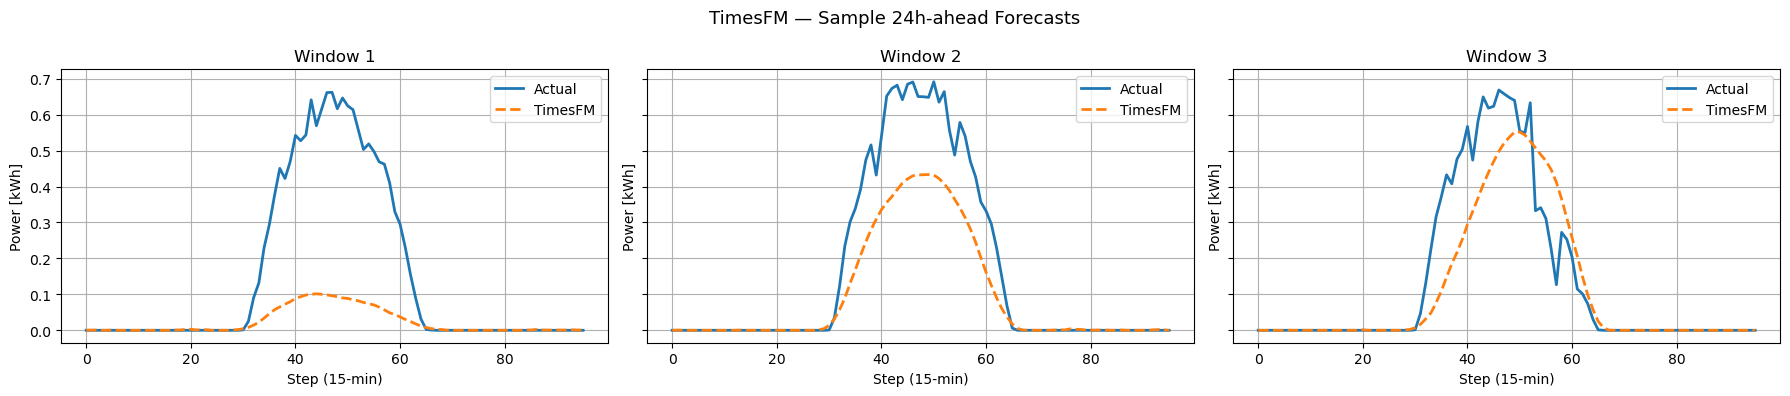

Saved → ../figure/04_timesfm_sample_forecasts.png


In [7]:
sunny_windows = [w for w in range(n) if all_actuals[w].max() > 0.01][:3]

fig, axes = plt.subplots(1, len(sunny_windows), figsize=(6 * len(sunny_windows), 4), sharey=True)
if len(sunny_windows) == 1:
    axes = [axes]

for ax, w in zip(axes, sunny_windows):
    ax.plot(all_actuals[w], label='Actual',  linewidth=2)
    ax.plot(all_preds[w],   label='TimesFM', linewidth=2, linestyle='--')
    ax.set_title(f'Window {w+1}')
    ax.set_xlabel('Step (15-min)'); ax.set_ylabel('Power [kWh]')
    ax.legend(); ax.grid(True)

plt.suptitle(f'{MODEL_NAME} — Sample 24h-ahead Forecasts', fontsize=13)
plt.tight_layout()
plt.savefig('../figure/04_timesfm_sample_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/04_timesfm_sample_forecasts.png')

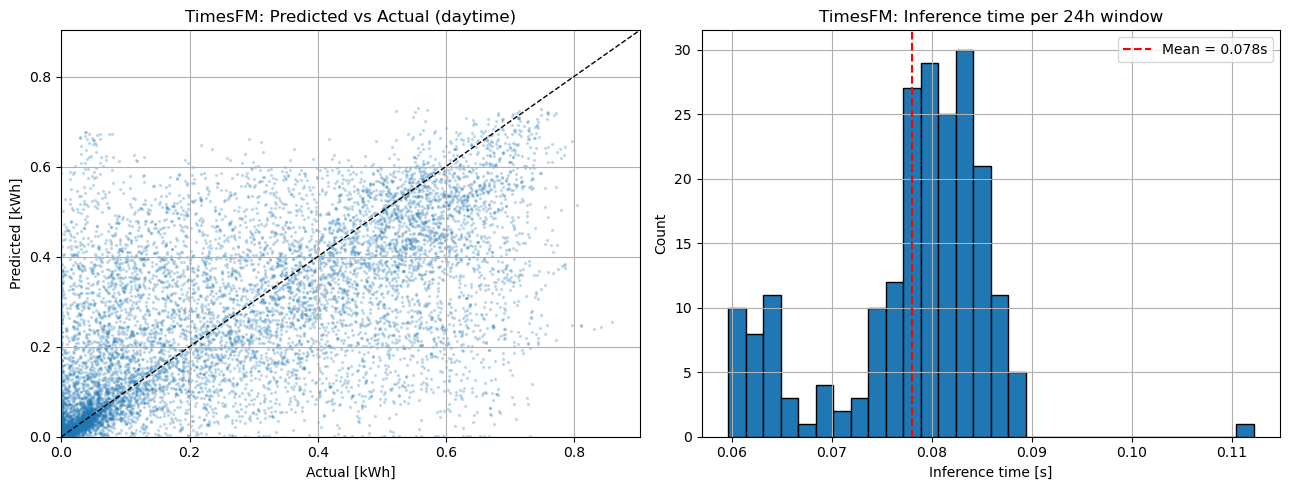

Saved → ../figure/04_timesfm_eval.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = max(actuals_flat[day_mask].max(), preds_flat[day_mask].max()) * 1.05
axes[0].scatter(actuals_flat[day_mask], preds_flat[day_mask], s=2, alpha=0.2)
axes[0].plot([0, lim], [0, lim], 'k--', linewidth=1)
axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel('Actual [kWh]'); axes[0].set_ylabel('Predicted [kWh]')
axes[0].set_title(f'{MODEL_NAME}: Predicted vs Actual (daytime)')
axes[0].grid(True)

axes[1].hist(infer_times, bins=30, edgecolor='black')
axes[1].axvline(avg_infer, color='red', linestyle='--', label=f'Mean = {avg_infer:.3f}s')
axes[1].set_xlabel('Inference time [s]'); axes[1].set_ylabel('Count')
axes[1].set_title(f'{MODEL_NAME}: Inference time per 24h window')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('../figure/04_timesfm_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/04_timesfm_eval.png')

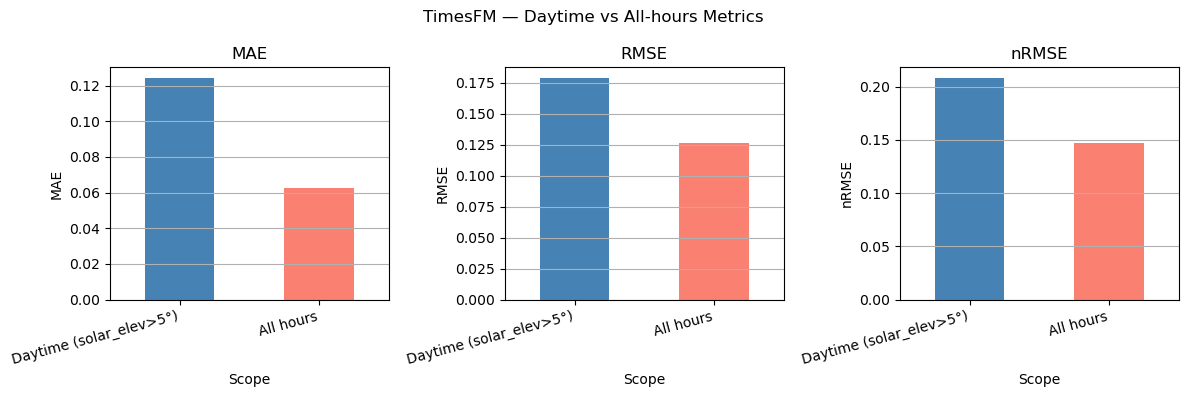

Saved → ../figure/04_timesfm_daytime_vs_allhours.png


In [9]:
metrics_df = pd.DataFrame({
    'Scope': ['Daytime (solar_elev>5°)', 'All hours'],
    'MAE':   [mae_d,   mae_a],
    'RMSE':  [rmse_d,  rmse_a],
    'nRMSE': [nrmse_d, nrmse_a],
})

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'nRMSE']):
    metrics_df.set_index('Scope')[col].plot(kind='bar', ax=ax, color=['steelblue', 'salmon'])
    ax.set_title(col); ax.set_ylabel(col); ax.grid(axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle(f'{MODEL_NAME} — Daytime vs All-hours Metrics', fontsize=12)
plt.tight_layout()
plt.savefig('../figure/04_timesfm_daytime_vs_allhours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ../figure/04_timesfm_daytime_vs_allhours.png')

## 6. Save Results

In [10]:
pd.DataFrame({
    'timestamp'  : ts_flat,
    'actual'     : actuals_flat,
    'timesfm'    : preds_flat,
    'solar_elev' : solar_elev,
    'daytime'    : day_mask,
}).to_pickle('../results/timesfm_predictions.pkl')
print('Saved → ../results/timesfm_predictions.pkl')

Saved → ../results/timesfm_predictions.pkl


In [11]:
comp_path = '../results/comparison.csv'
comp_cols = ['Model', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'Inference Time']

new_rows = pd.DataFrame([
    {'Model': MODEL_NAME,                'MAE': mae_d, 'RMSE': rmse_d, 'nRMSE': nrmse_d,
     'Train Time': 0.0, 'Inference Time': avg_infer},
    {'Model': f'{MODEL_NAME} (all-hrs)', 'MAE': mae_a, 'RMSE': rmse_a, 'nRMSE': nrmse_a,
     'Train Time': 0.0, 'Inference Time': avg_infer},
])

if os.path.exists(comp_path):
    existing = pd.read_csv(comp_path)
    existing = existing[~existing['Model'].isin(new_rows['Model'])]
    combined = pd.concat([existing, new_rows], ignore_index=True)
else:
    combined = new_rows

combined[comp_cols].to_csv(comp_path, index=False)
print(f'Saved → {comp_path}')
print()
print(combined[comp_cols].to_string(index=False))

Saved → ../results/comparison.csv

            Model      MAE     RMSE    nRMSE  Train Time  Inference Time
         LightGBM 0.021175 0.034823 0.040512    0.196141        0.014383
 LightGBM (tuned) 0.020895 0.034539 0.040182   66.418172        0.037487
              MLP 0.020945 0.034464 0.040095    2.954158        0.017441
          Chronos 0.164308 0.231903 0.269790    0.000000        1.622153
Chronos (all-hrs) 0.104663 0.188088 0.218817    0.000000        1.622153
          TimesFM 0.124079 0.178613 0.207794    0.000000        0.077968
TimesFM (all-hrs) 0.062519 0.126753 0.147461    0.000000        0.077968
